In [5]:
from src.exp import *

# healthy_train_cells, test_cells = get_health_divided_train_test(healthy_test_size=0.5)
# print(f'{len(healthy_train_cells)} healthy training cells; {len(test_cells)} mixed health test cells\n')

healthy_train_cells = [
    'data/preprocessed/1500mAh2-100S0C.pkl'
]

X_train = get_windows(cells=healthy_train_cells, window_size=100, window_skip=50)
print_data_stats(X_train)

Getting windows:   0%|          | 0/1 [00:00<?, ?it/s]


===TRAINING DATA STATS===
mean: 	38.863494873046875 
std: 	20.382450103759766 
min: 	23.982999801635742
max: 	93.00800323486328
shape:	 (11295, 100, 1)


1

In [1]:
from src.data import get_health_divided_loaders

train_loader, test_loader = get_health_divided_loaders(window_skip=500, preload=True)
print(f'\nTRAIN: {train_loader.dataset.window_size} x {len(train_loader.dataset)}')
print(f'TEST: {test_loader.dataset.window_size} x {len(test_loader.dataset)}')

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

Building dataset index...


100%|██████████| 81/81 [00:00<00:00, 946.42it/s]


Building dataset index...


100%|██████████| 252/252 [00:00<00:00, 4085.72it/s]


TRAIN: 1000 x 39947
TEST: 1000 x 27692


In [26]:
import tensorflow as tf 
import numpy as np
from tqdm.auto import tqdm
from src.data.train_test_split import get_health_divided_train_test
from src.data import BatteryData
import torch

def generator(cells, window_size=1000, window_skip=500):
    for filename in cells:
        battery = BatteryData.load(filename)
        for data in battery.timeseries_data:
            scaledx = data.to_numpy()[:, 1]
            temps = scaledx[~np.isnan(scaledx)]
            for i in range(0, len(temps) - window_size, max(1, window_skip or 1)):
                window = temps[i:i+window_size].astype(np.float32).reshape(window_size, 1)
                yield window

train_cells, test_cells = get_health_divided_train_test()

# Create tf.data.Dataset
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator(train_cells, window_size=1000),
    output_signature=tf.TensorSpec(shape=(1000, 1), dtype=tf.float32)
)

train_dataset = train_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

In [27]:
i=0
for x in tqdm(train_dataset): i+=1
print(i)

0it [00:00, ?it/s]

618


2025-10-15 17:51:24.233748: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [33]:
from tensorflow import keras 
from src.data.train_test_split import get_health_divided_train_test

train_cells, test_cells = get_health_divided_train_test()

sequence_length = 1000
batch_size = 64

datasets = []

for filename in train_cells:
    battery = BatteryData.load(filename)
    for data in battery.timeseries_data:
        scaledx = data.to_numpy()[:, 1]
        temps = scaledx[~np.isnan(scaledx)]
        # Drop sequences shorter than 1000
        if len(temps) < sequence_length:
            continue

        ds = keras.utils.timeseries_dataset_from_array(
            data=temps,
            targets=None,               # if you just want sequences
            sequence_length=sequence_length,
            sequence_stride=500,          # move 500 timestep at a time
            batch_size=batch_size,
            shuffle=False,
        )
        datasets.append(ds)

# Combine them into a single dataset
final_dataset = datasets[0]
for ds in datasets[1:]:
    final_dataset = final_dataset.concatenate(ds)
final_dataset.map(lambda x: (x, x))

print(final_dataset)
for dataset in final_dataset:
    print(dataset)
    break

# ds = keras.utils.timeseries_dataset_from_array

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

<_ConcatenateDataset element_spec=TensorSpec(shape=(None, None), dtype=tf.float64, name=None)>
tf.Tensor(
[[24.772 24.772 24.772 ... 28.639 28.955 28.709]
 [29.27  28.903 28.903 ... 27.454 28.035 28.109]
 [28.8   29.102 28.903 ... 28.933 29.007 28.964]
 ...
 [26.717 26.686 26.595 ... 28.139 27.896 28.242]
 [28.69  28.807 28.837 ... 26.516 26.442 26.295]
 [27.999 28.198 28.168 ... 25.543 25.512 25.66 ]], shape=(64, 1000), dtype=float64)


In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from src.data.train_test_split import get_health_divided_train_test
from src.data import BatteryData

sequence_length = 1000
batch_size = 64

train_cells, test_cells = get_health_divided_train_test()

# Function to load and process a single CSV file
def load_csv_and_make_dataset(filename):
    battery = BatteryData.load(filename)
    data = battery.timeseries_data[0]
    data = torch.tensor(data.to_numpy(), dtype=torch.float32)
    
    return tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=sequence_length,
        batch_size=None,  # Use batching later
        shuffle=False
    )

# Create a tf.data.Dataset from file paths
filenames_ds = tf.data.Dataset.from_tensor_slices(train_cells)

# Use flat_map to create a single dataset from all files
# tf.data.experimental.AUTOTUNE optimizes the number of parallel calls
combined_dataset = filenames_ds.flat_map(
    lambda x: tf.py_function(func=load_csv_and_make_dataset, inp=[x], Tout=tf.data.Dataset.from_tensors((tf.float64, tf.float64))))

# Reshape the data after combining (This step is crucial)
def reshape_data(inputs, targets):
    return tf.ensure_shape(inputs, [sequence_length, 1]), tf.ensure_shape(targets, [])

combined_dataset = combined_dataset.map(reshape_data)

# Combine and batch the final dataset
final_dataset = combined_dataset.unbatch().batch(batch_size)

# Optional: Print the structure of the dataset
for batch in final_dataset.take(1):
    inputs, targets = batch
    print(f"Inputs shape: {inputs.shape}")
    print(f"Targets shape: {targets.shape}")

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

Checking attributes:   0%|          | 0/333 [00:00<?, ?it/s]

2025-10-15 18:13:01.197167: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2025-10-15 18:13:01.197193: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2025-10-15 18:13:01.197201: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 24.00 GB
2025-10-15 18:13:01.197219: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-15 18:13:01.197232: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


TypeError: in user code:

    File "/var/folders/gq/nr1qyp1s0f76pz81bn_6vlzc0000gq/T/ipykernel_30917/1046125049.py", line 31, in None  *
        lambda x: tf.py_function(func=load_csv_and_make_dataset, inp=[x], Tout=tf.data.Dataset.from_tensors((tf.float64, tf.float64)))

    TypeError: Failed to convert elements of <dtype: 'float64'> to Tensor. Consider casting elements to a supported type. See https://www.tensorflow.org/api_docs/python/tf/dtypes for supported TF dtypes.


In [34]:
from tensorflow import keras 
from src.models import LSTMAutoencoder
import pickle

autoencoder_model = LSTMAutoencoder(training_data=final_dataset)
autoencoder_model.compile(optimizer='adam', 
                        loss='mse',
                        metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
history = autoencoder_model.fit(train_dataset, epochs=3, batch_size=64)

print("Training Loss:", history.history['loss'])
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['root_mean_squared_error'])

# Assuming 'model' is your trained model object
with open(trained_model_name(), 'wb') as file:
    pickle.dump(autoencoder_model, file)

Epoch 1/3


ValueError: None values not supported.

In [2]:
from tensorflow import keras 
from src.models import LSTMAutoencoder
import pickle

autoencoder_model = LSTMAutoencoder(training_data=train_loader)
autoencoder_model.compile(optimizer='adam', 
                        loss='mse',
                        metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
history = autoencoder_model.fit(X_train, X_train, epochs=3, batch_size=32)

print("Training Loss:", history.history['loss'])
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['root_mean_squared_error'])

# Assuming 'model' is your trained model object
with open(trained_model_name(), 'wb') as file:
    pickle.dump(autoencoder_model, file)

AttributeError: 'DataLoader' object has no attribute 'shape'

3235/3235 ━━━━━━━━━━━━━━━━━━━━ 278s 84ms/step
(103515, 100, 1) (103515, 100, 1)


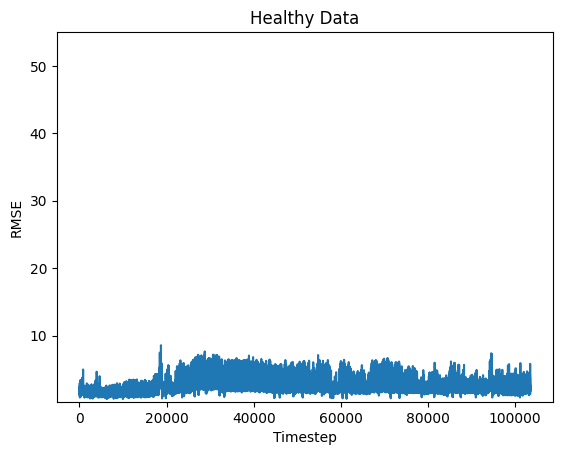

In [4]:
test_cells_healthy = [
    'data/preprocessed/UL-PUR_R15-EX4_18650_NCA_23C_2.5-96.5_0.5-0.5C_d_timeseries.pkl'
]
X_test, _, _ = get_windows(cells=test_cells_healthy, window_size=100)

healthy_predictions = autoencoder_model.predict(X_test)
print(healthy_predictions.shape, X_test.shape)
plot_results(X_test, healthy_predictions, 'Healthy Data')

In [5]:
test_cells_unhealthy = [
    'data/preprocessed/LFP_15Ah_60SOC_cell1_MAX.pkl'
]
X_test_unhealthy, _, _ = get_windows(cells=test_cells_unhealthy, window_size=100)

unhealthy_predictions = autoencoder_model.predict(X_test_unhealthy)
print(unhealthy_predictions.shape, X_test_unhealthy.shape)
plot_results(X_test_unhealthy, unhealthy_predictions, 'Unhealthy Data')

FileNotFoundError: [Errno 2] No such file or directory: 'data/preprocessed/LFP_15Ah_60SOC_cell1_MAX.pkl'

In [2]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices())

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
['/device:CPU:0']


In [12]:
tf.version.VERSION

'2.20.0'

In [6]:
import torch

device = torch.device("mps" if torch.mps.is_available() else "cpu")

device

device(type='mps')